[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000317 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 3275, number of used features: 5
[LightGBM] [Info] Start training from score 0.000947
STACKING MODEL RESULTS
RMSE: 0.0158470372598331
Direction Accuracy: 0.5457875457875457


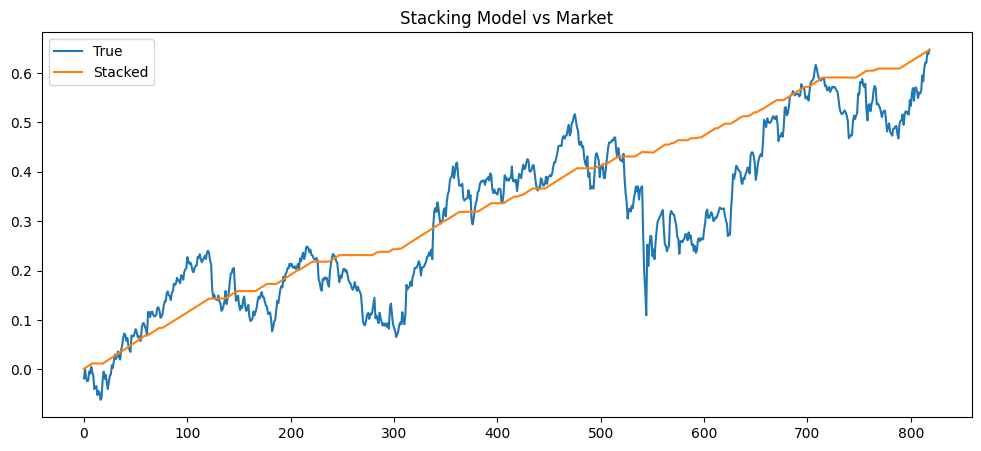

In [1]:

import yfinance as yf
import numpy as np
import pandas as pd

from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error

import lightgbm as lgb

ticker = "AAPL"

raw = yf.download(
    ticker,
    start="2010-01-01",
    progress=False,
    auto_adjust=False,
    threads=False
)

df = pd.DataFrame(index=raw.index)

for col in raw.columns:
    name = str(col).lower()
    if "close" in name:
        df["close"] = raw[col]

df = df.dropna()

df["log_return"] = np.log(df["close"] / df["close"].shift(1))
df["volatility"] = df["log_return"].rolling(20).std()
df["momentum"] = df["close"] / df["close"].shift(10) - 1
df["ma10"] = df["close"].rolling(10).mean()
df["ma20"] = df["close"].rolling(20).mean()

df = df.dropna()

y = df["log_return"].values
X = df.drop(columns=["log_return"])

split = int(len(df) * 0.8)

X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y[:split], y[split:]

lgb_model = lgb.LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42
)

lgb_model.fit(X_train, y_train)
lgb_pred = lgb_model.predict(X_test)

mean_pred = np.full(len(y_test), np.mean(y_train))

momentum_pred = np.sign(X_test["momentum"]) * np.std(y_train)

stack_X = np.column_stack([
    lgb_pred,
    mean_pred,
    momentum_pred
])

meta_model = Ridge()

meta_model.fit(stack_X, y_test)
final_pred = meta_model.predict(stack_X)

rmse = np.sqrt(mean_squared_error(y_test, final_pred))
direction_acc = np.mean(np.sign(y_test) == np.sign(final_pred))

print("STACKING MODEL RESULTS")
print("RMSE:", rmse)
print("Direction Accuracy:", direction_acc)

import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(np.cumsum(y_test), label="True")
plt.plot(np.cumsum(final_pred), label="Stacked")
plt.legend()
plt.title("Stacking Model vs Market")
plt.show()